In [1]:
import matplotlib
#matplotlib.use('Agg')  # Use non-interactive backend
import matplotlib.pyplot as plt

In [2]:
!pip3 install pandas numpy matplotlib seaborn scikit-learn
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split

print("All libraries imported successfully!")
import pandas as pd
df = pd.read_csv("../data/diabetic_data.csv")


[notice] A new release of pip is available: 25.2 -> 26.0.1
[notice] To update, run: pip install --upgrade pip
All libraries imported successfully!


In [3]:
df.dtypes


encounter_id                 int64
patient_nbr                  int64
race                        object
gender                      object
age                         object
weight                      object
admission_type_id            int64
discharge_disposition_id     int64
admission_source_id          int64
time_in_hospital             int64
payer_code                  object
medical_specialty           object
num_lab_procedures           int64
num_procedures               int64
num_medications              int64
number_outpatient            int64
number_emergency             int64
number_inpatient             int64
diag_1                      object
diag_2                      object
diag_3                      object
number_diagnoses             int64
max_glu_serum               object
A1Cresult                   object
metformin                   object
repaglinide                 object
nateglinide                 object
chlorpropamide              object
glimepiride         

In [4]:
print("Original shape :" , df.shape)

Original shape : (101766, 50)


In [5]:
df.replace('?', np.nan, inplace=True)
df['race'] = df['race'].fillna('Unknown')
df['medical_specialty'] = df['medical_specialty'].fillna('Unknown')
df['diag_1'] = df['diag_1'].fillna('Unknown')
df['diag_2'] = df['diag_2'].fillna('Unknown')
df['diag_3'] = df['diag_3'].fillna('Unknown')

In [6]:
df.isnull().sum()

encounter_id                    0
patient_nbr                     0
race                            0
gender                          0
age                             0
weight                      98569
admission_type_id               0
discharge_disposition_id        0
admission_source_id             0
time_in_hospital                0
payer_code                  40256
medical_specialty               0
num_lab_procedures              0
num_procedures                  0
num_medications                 0
number_outpatient               0
number_emergency                0
number_inpatient                0
diag_1                          0
diag_2                          0
diag_3                          0
number_diagnoses                0
max_glu_serum               96420
A1Cresult                   84748
metformin                       0
repaglinide                     0
nateglinide                     0
chlorpropamide                  0
glimepiride                     0
acetohexamide 

In [7]:
df['readmitted_30'] = (df['readmitted'] == '<30').astype(int)
print(df['readmitted_30'].value_counts())

readmitted_30
0    90409
1    11357
Name: count, dtype: int64


In [8]:
df.drop(columns=['weight', 'max_glu_serum', 'A1Cresult', 'encounter_id', 'patient_nbr', 'payer_code', 'readmitted'], inplace=True)
print("Shape after dropping : ", df.shape)

Shape after dropping :  (101766, 44)


In [9]:
top_specialties = df['medical_specialty'].value_counts().nlargest(10).index
df['medical_specialty'] = df['medical_specialty'].apply(
    lambda x: x if x in top_specialties else 'Other'
)
print(df['medical_specialty'].value_counts())
print("Unique values:", df['medical_specialty'].nunique())

medical_specialty
Unknown                       49949
InternalMedicine              14635
Other                          8340
Emergency/Trauma               7565
Family/GeneralPractice         7440
Cardiology                     5352
Surgery-General                3099
Nephrology                     1613
Orthopedics                    1400
Orthopedics-Reconstructive     1233
Radiologist                    1140
Name: count, dtype: int64
Unique values: 11


In [10]:
age_map = {
    '[0-10)': 0, '[10-20)': 1, '[20-30)': 2, '[30-40)': 3,
    '[40-50)': 4, '[50-60)': 5, '[60-70)': 6, '[70-80)': 7,
    '[80-90)': 8, '[90-100)': 9
}
df['age'] = df['age'].map(age_map)

In [11]:
med_map = {'No': 0, 'Steady': 1, 'Up': 2, 'Down': 3}
med_cols = ['metformin', 'repaglinide', 'nateglinide', 'chlorpropamide',
            'glimepiride', 'acetohexamide', 'glipizide', 'glyburide',
            'tolbutamide', 'pioglitazone', 'rosiglitazone', 'acarbose',
            'miglitol', 'troglitazone', 'tolazamide', 'examide',
            'citoglipton', 'insulin', 'glyburide-metformin',
            'glipizide-metformin', 'glimepiride-pioglitazone',
            'metformin-rosiglitazone', 'metformin-pioglitazone']
for col in med_cols:
    df[col] = df[col].map(med_map)

In [12]:
df['change'] = df['change'].map({'No': 0, 'Ch': 1})
df['diabetesMed'] = df['diabetesMed'].map({'No': 0, 'Yes': 1})
df['gender'] = df['gender'].map({'Male': 0, 'Female': 1, 'Unknown/Invalid': -1})

In [13]:
print("Final shape:", df.shape)
print("Null count:", df.isnull().sum().sum())
print(df.head())

Final shape: (101766, 44)
Null count: 0
              race  gender  age  admission_type_id  discharge_disposition_id  \
0        Caucasian       1    0                  6                        25   
1        Caucasian       1    1                  1                         1   
2  AfricanAmerican       1    2                  1                         1   
3        Caucasian       0    3                  1                         1   
4        Caucasian       0    4                  1                         1   

   admission_source_id  time_in_hospital medical_specialty  \
0                    1                 1             Other   
1                    7                 3           Unknown   
2                    7                 2           Unknown   
3                    7                 2           Unknown   
4                    7                 1           Unknown   

   num_lab_procedures  num_procedures  ...  citoglipton  insulin  \
0                  41               0 

In [14]:
print(df['diag_1'].value_counts().head(20))
print("Unique values:", df['diag_1'].nunique())

diag_1
428      6862
414      6581
786      4016
410      3614
486      3508
427      2766
491      2275
715      2151
682      2042
434      2028
780      2019
996      1967
276      1889
38       1688
250.8    1680
599      1595
584      1520
V57      1207
250.6    1183
518      1115
Name: count, dtype: int64
Unique values: 717


In [15]:
def map_diag(code):
    try:
        code = str(code)
        if code == 'Unknown':
            return 'Other'
        if code.startswith('E') or code.startswith('V'):
            return 'Other'
        c = float(code)
        if 390 <= c <= 459 or c == 785: return 'Circulatory'
        if 460 <= c <= 519 or c == 786: return 'Respiratory'
        if 520 <= c <= 579 or c == 787: return 'Digestive'
        if 250 <= c <= 250.99:          return 'Diabetes'
        if 800 <= c <= 999:             return 'Injury'
        if 710 <= c <= 739:             return 'Musculoskeletal'
        if 580 <= c <= 629 or c == 788: return 'Genitourinary'
        if 140 <= c <= 239:             return 'Neoplasms'
        return 'Other'
    except:
        return 'Other'

df['diag_1'] = df['diag_1'].apply(map_diag)
df['diag_2'] = df['diag_2'].apply(map_diag)
df['diag_3'] = df['diag_3'].apply(map_diag)

print(df['diag_1'].value_counts())

diag_1
Circulatory        30437
Other              18193
Respiratory        14423
Digestive           9475
Diabetes            8757
Injury              6974
Genitourinary       5117
Musculoskeletal     4957
Neoplasms           3433
Name: count, dtype: int64


In [16]:
cat_cols = ['race', 'medical_specialty', 'diag_1', 'diag_2', 'diag_3']
df = pd.get_dummies(df, columns=cat_cols, drop_first=True)

print("Final shape:", df.shape)
print("Null count:", df.isnull().sum().sum())

Final shape: (101766, 78)
Null count: 0


In [17]:
X = df.drop(columns=['readmitted_30'])
y = df['readmitted_30']

print("X shape:", X.shape)
print("y shape:", y.shape)
print("Target distribution:\n", y.value_counts())

X shape: (101766, 77)
y shape: (101766,)
Target distribution:
 readmitted_30
0    90409
1    11357
Name: count, dtype: int64


In [18]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Training set size:", X_train.shape)
print("Test set size:", X_test.shape)
print("Train target distribution:\n", y_train.value_counts())

Training set size: (81412, 77)
Test set size: (20354, 77)
Train target distribution:
 readmitted_30
0    72326
1     9086
Name: count, dtype: int64


In [19]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Scaling done. Sample mean (should be ~0):", X_train_scaled.mean().round(4))

Scaling done. Sample mean (should be ~0): 0.0


In [20]:
from sklearn.linear_model import LogisticRegression

lr_model = LogisticRegression(
    class_weight='balanced',
    random_state=42,
    max_iter=1000
)

lr_model.fit(X_train_scaled, y_train)
print("Model trained successfully!")

Model trained successfully!


/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: divide by zero encountered in matmul
  raw_prediction = X @ weights + intercept
/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: overflow encountered in matmul
  raw_prediction = X @ weights + intercept
/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: invalid value encountered in matmul
  raw_prediction = X @ weights + intercept
/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/sklearn/linear_model/_linear_loss.py:330: RuntimeWarning: divide by zero encountered in matmul
  grad[:n_features] = X.T @ grad_pointwise + l2_reg_strength * weights
/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/sklearn/linear_model/_linea

In [21]:
# Check if any infinite or NaN values crept in after scaling
print("Inf count:", np.isinf(X_train_scaled).sum().sum())
print("NaN count:", np.isnan(X_train_scaled).sum().sum())

# Check the range of values
print("Max value:", X_train_scaled.max().round(2))
print("Min value:", X_train_scaled.min().round(2))
print("Mean:", X_train_scaled.mean().round(4))

Inf count: 0
NaN count: 0
Max value: 285.33
Min value: -3.82
Mean: 0.0


In [22]:
import pandas as pd

# Convert scaled array back to dataframe to inspect columns
X_train_scaled_df = pd.DataFrame(X_train_scaled, columns=X_train.columns)

# Find columns with extreme values
print("Columns with max absolute value > 10:")
for col in X_train_scaled_df.columns:
    max_val = X_train_scaled_df[col].abs().max()
    if max_val > 10:
        print(f"  {col}: max={max_val:.2f}")

Columns with max absolute value > 10:
  number_outpatient: max=30.46
  number_emergency: max=78.41
  number_inpatient: max=16.09
  repaglinide: max=20.42
  nateglinide: max=32.85
  chlorpropamide: max=91.26
  glimepiride: max=10.91
  tolbutamide: max=71.32
  pioglitazone: max=10.18
  rosiglitazone: max=11.04
  acarbose: max=50.72
  miglitol: max=112.40
  tolazamide: max=92.57
  glyburide-metformin: max=34.72
  glipizide-metformin: max=100.87
  glimepiride-pioglitazone: max=285.33
  metformin-rosiglitazone: max=201.75
  metformin-pioglitazone: max=285.33
  race_Asian: max=12.50


In [23]:
# Check how many non-zero values these extreme columns have
extreme_cols = ['glimepiride-pioglitazone', 'metformin-rosiglitazone', 
                'metformin-pioglitazone', 'glipizide-metformin',
                'miglitol', 'tolazamide', 'chlorpropamide', 'tolbutamide',
                'acarbose', 'nateglinide', 'repaglinide', 'glyburide-metformin']

print("Non-zero counts out of", len(X_train), "training rows:")
for col in extreme_cols:
    nonzero = (X_train[col] != 0).sum()
    pct = (nonzero / len(X_train) * 100).round(2)
    print(f"  {col}: {nonzero} non-zero ({pct}%)")

Non-zero counts out of 81412 training rows:
  glimepiride-pioglitazone: 1 non-zero (0.0%)
  metformin-rosiglitazone: 2 non-zero (0.0%)
  metformin-pioglitazone: 1 non-zero (0.0%)
  glipizide-metformin: 8 non-zero (0.01%)
  miglitol: 28 non-zero (0.03%)
  tolazamide: 35 non-zero (0.04%)
  chlorpropamide: 68 non-zero (0.08%)
  tolbutamide: 16 non-zero (0.02%)
  acarbose: 245 non-zero (0.3%)
  nateglinide: 551 non-zero (0.68%)
  repaglinide: 1225 non-zero (1.5%)
  glyburide-metformin: 551 non-zero (0.68%)


In [24]:
# Drop columns where less than 1% of patients have non-zero values
threshold = 0.01  # 1%

cols_to_drop = []
for col in X_train.columns:
    nonzero_pct = (X_train[col] != 0).sum() / len(X_train)
    if nonzero_pct < threshold:
        cols_to_drop.append(col)

print(f"Dropping {len(cols_to_drop)} near-empty columns:")
print(cols_to_drop)

# Drop from both X_train and X_test
X_train = X_train.drop(columns=cols_to_drop)
X_test = X_test.drop(columns=cols_to_drop)

print("\nNew X_train shape:", X_train.shape)

Dropping 16 near-empty columns:
['nateglinide', 'chlorpropamide', 'acetohexamide', 'tolbutamide', 'acarbose', 'miglitol', 'troglitazone', 'tolazamide', 'examide', 'citoglipton', 'glyburide-metformin', 'glipizide-metformin', 'glimepiride-pioglitazone', 'metformin-rosiglitazone', 'metformin-pioglitazone', 'race_Asian']

New X_train shape: (81412, 61)


In [25]:
# Rescale with clean data
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Check max value is reasonable now
print("New max value:", X_train_scaled.max().round(2))
print("New min value:", X_train_scaled.min().round(2))

# Retrain logistic regression
lr_model = LogisticRegression(
    class_weight='balanced',
    random_state=42,
    max_iter=1000
)
lr_model.fit(X_train_scaled, y_train)
print("Model retrained successfully!")

/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: divide by zero encountered in matmul
  raw_prediction = X @ weights + intercept
/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: overflow encountered in matmul
  raw_prediction = X @ weights + intercept
/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: invalid value encountered in matmul
  raw_prediction = X @ weights + intercept
/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/sklearn/linear_model/_linear_loss.py:330: RuntimeWarning: divide by zero encountered in matmul
  grad[:n_features] = X.T @ grad_pointwise + l2_reg_strength * weights
/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/sklearn/linear_model/_linea

New max value: 78.41
New min value: -3.82
Model retrained successfully!


In [26]:
# Check the raw distribution of numeric columns with outliers
problematic = ['number_outpatient', 'number_emergency', 'number_inpatient']

for col in problematic:
    print(f"\n{col}:")
    print(f"  Mean: {X_train[col].mean():.2f}")
    print(f"  Median: {X_train[col].median():.2f}")
    print(f"  Max: {X_train[col].max():.2f}")
    print(f"  99th percentile: {X_train[col].quantile(0.99):.2f}")
    print(f"  Values > 10: {(X_train[col] > 10).sum()}")


number_outpatient:
  Mean: 0.37
  Median: 0.00
  Max: 39.00
  99th percentile: 5.00
  Values > 10: 187

number_emergency:
  Mean: 0.20
  Median: 0.00
  Max: 76.00
  99th percentile: 3.00
  Values > 10: 70

number_inpatient:
  Mean: 0.64
  Median: 0.00
  Max: 21.00
  99th percentile: 6.00
  Values > 10: 109


In [27]:
# Clip outliers at 99th percentile for skewed numeric columns
skewed_cols = ['number_outpatient', 'number_emergency', 'number_inpatient']

for col in skewed_cols:
    # Calculate 99th percentile FROM TRAINING DATA ONLY
    cap = X_train[col].quantile(0.99)
    
    # Apply the same cap to both train and test
    X_train[col] = X_train[col].clip(upper=cap)
    X_test[col] = X_test[col].clip(upper=cap)
    
    print(f"{col} capped at {cap}. New max: {X_train[col].max()}")

# Rescale again with clipped data
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("\nNew max after clipping:", X_train_scaled.max().round(2))
print("New min after clipping:", X_train_scaled.min().round(2))

# Retrain
lr_model = LogisticRegression(
    class_weight='balanced',
    random_state=42,
    max_iter=1000
)
lr_model.fit(X_train_scaled, y_train)
print("\nModel retrained successfully!")

number_outpatient capped at 5.0. New max: 5
number_emergency capped at 3.0. New max: 3
number_inpatient capped at 6.0. New max: 6

New max after clipping: 20.42
New min after clipping: -3.82

Model retrained successfully!


/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: divide by zero encountered in matmul
  raw_prediction = X @ weights + intercept
/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: overflow encountered in matmul
  raw_prediction = X @ weights + intercept
/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: invalid value encountered in matmul
  raw_prediction = X @ weights + intercept
/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/sklearn/linear_model/_linear_loss.py:330: RuntimeWarning: divide by zero encountered in matmul
  grad[:n_features] = X.T @ grad_pointwise + l2_reg_strength * weights
/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/sklearn/linear_model/_linea

In [28]:
# Find ALL remaining columns still causing problems
X_train_scaled_df = pd.DataFrame(X_train_scaled, columns=X_train.columns)

print("Columns still above 10 after scaling:")
for col in X_train_scaled_df.columns:
    max_val = X_train_scaled_df[col].abs().max()
    if max_val > 10:
        print(f"  {col}: max={max_val:.2f}, non-zero%={((X_train[col] != 0).sum()/len(X_train)*100):.2f}%")

Columns still above 10 after scaling:
  repaglinide: max=20.42, non-zero%=1.50%
  glimepiride: max=10.91, non-zero%=5.10%
  pioglitazone: max=10.18, non-zero%=7.18%
  rosiglitazone: max=11.04, non-zero%=6.29%


In [29]:
# Get all medication columns that are still encoded as 0/1/2/3
med_cols_remaining = ['repaglinide', 'glimepiride', 'pioglitazone', 'rosiglitazone',
                      'metformin', 'acetohexamide', 'glipizide', 'glyburide',
                      'insulin', 'change', 'diabetesMed']

for col in med_cols_remaining:
    if col in X_train.columns:
        cap = X_train[col].quantile(0.99)
        X_train[col] = X_train[col].clip(upper=cap)
        X_test[col] = X_test[col].clip(upper=cap)

# Rescale with fully clipped data
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Final check
X_train_scaled_df = pd.DataFrame(X_train_scaled, columns=X_train.columns)
remaining_extreme = []
for col in X_train_scaled_df.columns:
    max_val = X_train_scaled_df[col].abs().max()
    if max_val > 10:
        remaining_extreme.append(f"{col}: {max_val:.2f}")

if remaining_extreme:
    print("Still problematic:", remaining_extreme)
else:
    print("All columns clean! Max scaled value:", X_train_scaled.max().round(2))

# Retrain
lr_model = LogisticRegression(
    class_weight='balanced',
    random_state=42,
    max_iter=1000
)
lr_model.fit(X_train_scaled, y_train)
print("Model retrained successfully!")

All columns clean! Max scaled value: 9.42
Model retrained successfully!


/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: divide by zero encountered in matmul
  raw_prediction = X @ weights + intercept
/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: overflow encountered in matmul
  raw_prediction = X @ weights + intercept
/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: invalid value encountered in matmul
  raw_prediction = X @ weights + intercept
/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/sklearn/linear_model/_linear_loss.py:330: RuntimeWarning: divide by zero encountered in matmul
  grad[:n_features] = X.T @ grad_pointwise + l2_reg_strength * weights
/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/sklearn/linear_model/_linea

In [30]:
lr_model = LogisticRegression(
    class_weight='balanced',
    random_state=42,
    max_iter=1000,
    solver='saga',      # better solver for large datasets
    C=0.1              # stronger regularization to prevent weight explosion
)
lr_model.fit(X_train_scaled, y_train)
print("Model trained successfully!")

Model trained successfully!


Classification Report:
                precision    recall  f1-score   support

Not Readmitted       0.92      0.68      0.78     18083
    Readmitted       0.17      0.54      0.26      2271

      accuracy                           0.66     20354
     macro avg       0.55      0.61      0.52     20354
  weighted avg       0.84      0.66      0.72     20354

ROC-AUC Score: 0.6508


/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: in

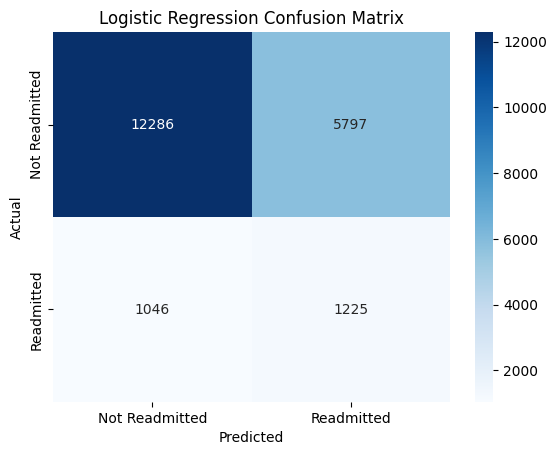

In [31]:
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
import seaborn as sns
import matplotlib.pyplot as plt

y_pred = lr_model.predict(X_test_scaled)
y_prob = lr_model.predict_proba(X_test_scaled)[:, 1]

print("Classification Report:")
print(classification_report(y_test, y_pred, target_names=['Not Readmitted', 'Readmitted']))

# Fixed line
print("ROC-AUC Score:", round(roc_auc_score(y_test, y_prob), 4))

cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Not Readmitted', 'Readmitted'],
            yticklabels=['Not Readmitted', 'Readmitted'])
plt.title('Logistic Regression Confusion Matrix')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.savefig('lr_confusion_matrix.png', bbox_inches='tight')
plt.show()
plt.close()

ROC-AUC Score: 0.6508


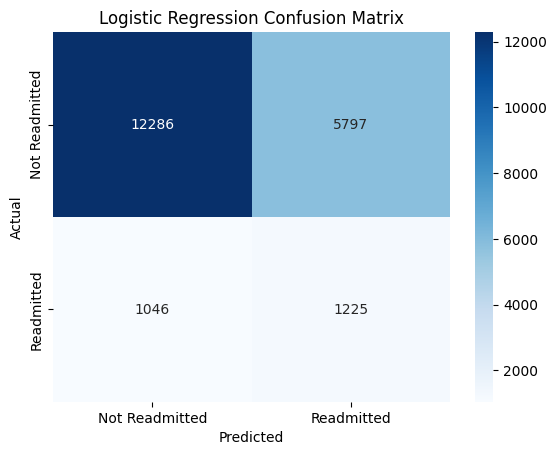

In [32]:
# Fix - round differently
print("ROC-AUC Score:", round(roc_auc_score(y_test, y_prob), 4))

# Plot confusion matrix
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Not Readmitted', 'Readmitted'],
            yticklabels=['Not Readmitted', 'Readmitted'])
plt.title('Logistic Regression Confusion Matrix')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()

In [33]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=100,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train, y_train)  # No scaling needed for Random Forest
print("Random Forest trained successfully!")

Random Forest trained successfully!


Classification Report:
                precision    recall  f1-score   support

Not Readmitted       0.89      1.00      0.94     18083
    Readmitted       0.58      0.00      0.01      2271

      accuracy                           0.89     20354
     macro avg       0.73      0.50      0.48     20354
  weighted avg       0.85      0.89      0.84     20354

ROC-AUC Score: 0.6463


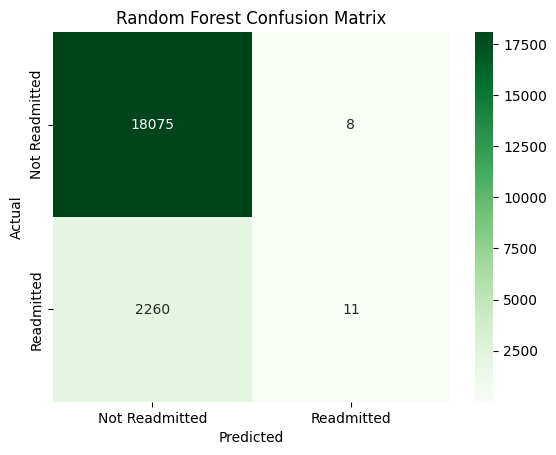

In [34]:
# Get predictions - using unscaled data this time
y_pred_rf = rf_model.predict(X_test)
y_prob_rf = rf_model.predict_proba(X_test)[:, 1]

# Classification report
print("Classification Report:")
print(classification_report(y_test, y_pred_rf, target_names=['Not Readmitted', 'Readmitted']))

# ROC-AUC
print("ROC-AUC Score:", round(roc_auc_score(y_test, y_prob_rf), 4))

# Confusion matrix
cm_rf = confusion_matrix(y_test, y_pred_rf)
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Greens',
            xticklabels=['Not Readmitted', 'Readmitted'],
            yticklabels=['Not Readmitted', 'Readmitted'])
plt.title('Random Forest Confusion Matrix')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()

In [35]:
!pip install imbalanced-learn


[notice] A new release of pip is available: 25.2 -> 26.0.1
[notice] To update, run: pip install --upgrade pip


In [36]:
# Install and import SMOTE
from imblearn.over_sampling import SMOTE

# Apply SMOTE to training data only
smote = SMOTE(random_state=42)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train, y_train)

print("Before SMOTE:", y_train.value_counts().to_dict())
print("After SMOTE:", pd.Series(y_train_resampled).value_counts().to_dict())

/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b


Before SMOTE: {0: 72326, 1: 9086}
After SMOTE: {0: 72326, 1: 72326}


In [37]:
# Retrain Random Forest on SMOTE-balanced data
rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
    # No class_weight='balanced' needed anymore - SMOTE already balanced the data
)

rf_model.fit(X_train_resampled, y_train_resampled)
print("Random Forest trained on balanced data successfully!")

Random Forest trained on balanced data successfully!


Classification Report:
                precision    recall  f1-score   support

Not Readmitted       0.89      0.96      0.92     18083
    Readmitted       0.13      0.05      0.08      2271

      accuracy                           0.86     20354
     macro avg       0.51      0.51      0.50     20354
  weighted avg       0.81      0.86      0.83     20354

ROC-AUC Score: 0.5885


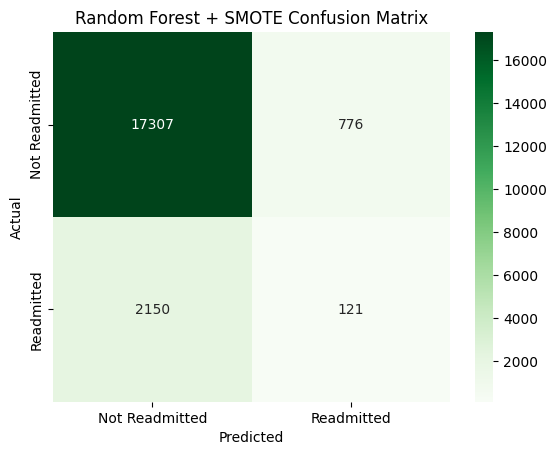

In [38]:
y_pred_rf = rf_model.predict(X_test)
y_prob_rf = rf_model.predict_proba(X_test)[:, 1]

print("Classification Report:")
print(classification_report(y_test, y_pred_rf, target_names=['Not Readmitted', 'Readmitted']))
print("ROC-AUC Score:", round(roc_auc_score(y_test, y_prob_rf), 4))

cm_rf = confusion_matrix(y_test, y_pred_rf)
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Greens',
            xticklabels=['Not Readmitted', 'Readmitted'],
            yticklabels=['Not Readmitted', 'Readmitted'])
plt.title('Random Forest + SMOTE Confusion Matrix')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()

In [39]:
!pip install xgboost

from xgboost import XGBClassifier

# Calculate imbalance ratio for scale_pos_weight
neg = (y_train == 0).sum()
pos = (y_train == 1).sum()
scale = neg / pos
print(f"scale_pos_weight: {scale:.2f}")

xgb_model = XGBClassifier(
    n_estimators=200,
    max_depth=4,
    learning_rate=0.05,
    scale_pos_weight=scale,
    random_state=42,
    eval_metric='auc',
    n_jobs=-1
)

xgb_model.fit(X_train, y_train)  # Original unbalanced data, not SMOTE
print("XGBoost trained successfully!")


[notice] A new release of pip is available: 25.2 -> 26.0.1
[notice] To update, run: pip install --upgrade pip
scale_pos_weight: 7.96
XGBoost trained successfully!


Classification Report:
                precision    recall  f1-score   support

Not Readmitted       0.93      0.64      0.76     18083
    Readmitted       0.18      0.61      0.28      2271

      accuracy                           0.64     20354
     macro avg       0.55      0.63      0.52     20354
  weighted avg       0.85      0.64      0.71     20354

ROC-AUC Score: 0.6834


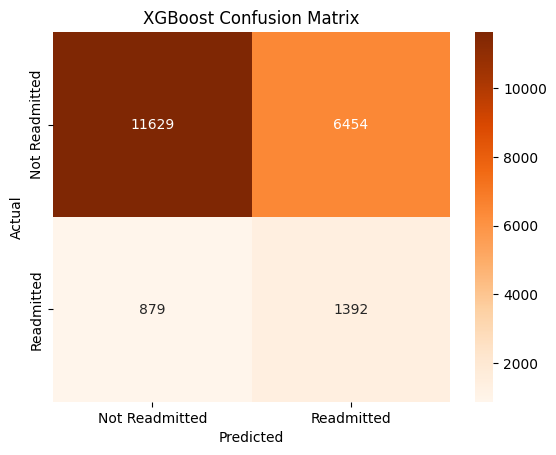

In [40]:
import warnings
warnings.filterwarnings('ignore')

y_pred_xgb = xgb_model.predict(X_test)
y_prob_xgb = xgb_model.predict_proba(X_test)[:, 1]

print("Classification Report:")
print(classification_report(y_test, y_pred_xgb, target_names=['Not Readmitted', 'Readmitted']))
print("ROC-AUC Score:", round(roc_auc_score(y_test, y_prob_xgb), 4))

cm_xgb = confusion_matrix(y_test, y_pred_xgb)
sns.heatmap(cm_xgb, annot=True, fmt='d', cmap='Oranges',
            xticklabels=['Not Readmitted', 'Readmitted'],
            yticklabels=['Not Readmitted', 'Readmitted'])
plt.title('XGBoost Confusion Matrix')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()

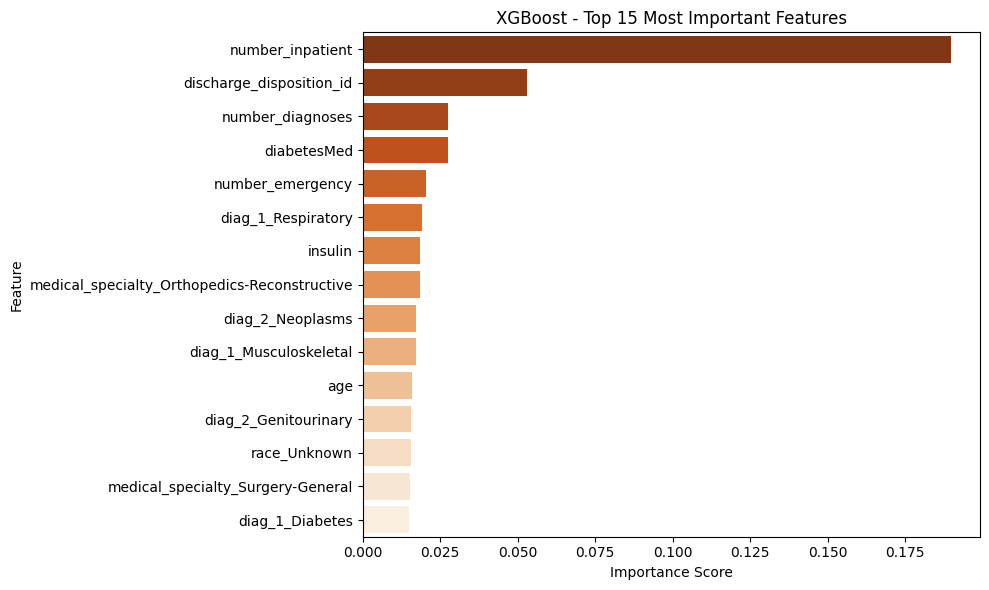

In [41]:
import pandas as pd

# Get feature importances
importance_df = pd.DataFrame({
    'feature': X_train.columns,
    'importance': xgb_model.feature_importances_
}).sort_values('importance', ascending=False).head(15)

# Plot
plt.figure(figsize=(10, 6))
sns.barplot(data=importance_df, x='importance', y='feature', palette='Oranges_r')
plt.title('XGBoost - Top 15 Most Important Features')
plt.xlabel('Importance Score')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

In [42]:
import numpy as np

# Get probabilities from XGBoost
y_prob_xgb = xgb_model.predict_proba(X_test)[:, 1]

# Test different thresholds and see how metrics change
thresholds = [0.1, 0.2, 0.3, 0.4, 0.5]

print(f"{'Threshold':<12} {'Recall(Readmitted)':<22} {'Precision(Readmitted)':<24} {'Caught/Total'}")
print("-" * 75)

for thresh in thresholds:
    y_pred_thresh = (y_prob_xgb >= thresh).astype(int)
    
    from sklearn.metrics import recall_score, precision_score
    recall = recall_score(y_test, y_pred_thresh)
    precision = precision_score(y_test, y_pred_thresh)
    caught = y_pred_thresh[y_test == 1].sum()
    total = (y_test == 1).sum()
    
    print(f"{thresh:<12} {recall:<22.3f} {precision:<24.3f} {caught}/{total}")

Threshold    Recall(Readmitted)     Precision(Readmitted)    Caught/Total
---------------------------------------------------------------------------
0.1          1.000                  0.112                    2271/2271
0.2          0.999                  0.114                    2268/2271
0.3          0.972                  0.120                    2208/2271
0.4          0.841                  0.145                    1909/2271
0.5          0.613                  0.177                    1392/2271


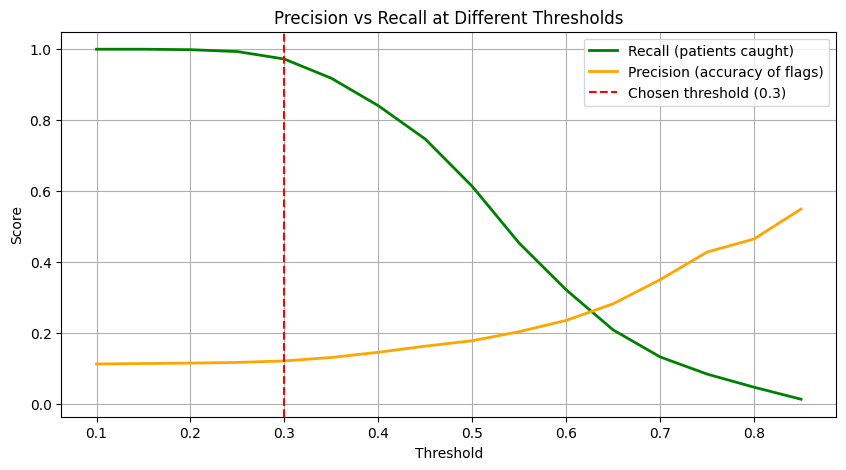

=== FINAL MODEL PERFORMANCE (threshold=0.3) ===
                precision    recall  f1-score   support

Not Readmitted       0.97      0.11      0.19     18083
    Readmitted       0.12      0.97      0.21      2271

      accuracy                           0.20     20354
     macro avg       0.54      0.54      0.20     20354
  weighted avg       0.87      0.20      0.20     20354

ROC-AUC: 0.6834


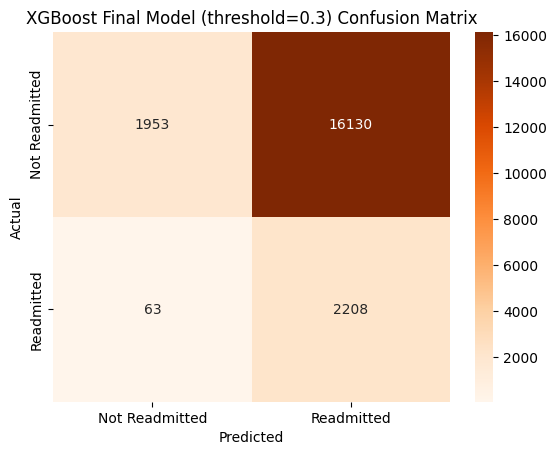

In [43]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import recall_score, precision_score, confusion_matrix
import seaborn as sns

# Plot the tradeoff curve
thresholds = np.arange(0.1, 0.9, 0.05)
recalls = []
precisions = []

for thresh in thresholds:
    y_pred_thresh = (y_prob_xgb >= thresh).astype(int)
    recalls.append(recall_score(y_test, y_pred_thresh))
    precisions.append(precision_score(y_test, y_pred_thresh, zero_division=0))

plt.figure(figsize=(10, 5))
plt.plot(thresholds, recalls, label='Recall (patients caught)', color='green', linewidth=2)
plt.plot(thresholds, precisions, label='Precision (accuracy of flags)', color='orange', linewidth=2)
plt.axvline(x=0.3, color='red', linestyle='--', label='Chosen threshold (0.3)')
plt.xlabel('Threshold')
plt.ylabel('Score')
plt.title('Precision vs Recall at Different Thresholds')
plt.legend()
plt.grid(True)
plt.show()

# Apply the chosen threshold of 0.3
best_threshold = 0.3
y_pred_final = (y_prob_xgb >= best_threshold).astype(int)

print("=== FINAL MODEL PERFORMANCE (threshold=0.3) ===")
from sklearn.metrics import classification_report, roc_auc_score
print(classification_report(y_test, y_pred_final, 
      target_names=['Not Readmitted', 'Readmitted']))
print("ROC-AUC:", round(roc_auc_score(y_test, y_prob_xgb), 4))

# Final confusion matrix
cm_final = confusion_matrix(y_test, y_pred_final)
sns.heatmap(cm_final, annot=True, fmt='d', cmap='Oranges',
            xticklabels=['Not Readmitted', 'Readmitted'],
            yticklabels=['Not Readmitted', 'Readmitted'])
plt.title('XGBoost Final Model (threshold=0.3) Confusion Matrix')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()